# 

In [1]:
# 1. Импорты и общие настройки
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict
from typing import List, Dict, Tuple, Optional

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import transforms, datasets, models
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from PIL import Image

# Фиксация seed для воспроизводимости
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

# Пути для артефактов
ARTIFACTS_DIR = "artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

Device: cuda
PyTorch: 2.7.1+cu118


In [2]:
# 2. Конфигурация
@dataclass
class ExperimentConfig:
    # Общие
    seed: int = 42
    batch_size: int = 64
    num_workers: int = 2
    
    # Классификация
    clf_epochs: int = 5  # Уменьшено для демо, в реальности 10-20
    clf_lr: float = 1e-3
    input_size: int = 32
    
    # Сегментация
    seg_batch_size: int = 4
    seg_threshold: float = 0.5
    
    # Режимы
    fast_mode: bool = True  # Включите False для полноценного обучения

cfg = ExperimentConfig()
print(asdict(cfg))

{'seed': 42, 'batch_size': 64, 'num_workers': 2, 'clf_epochs': 5, 'clf_lr': 0.001, 'input_size': 32, 'seg_batch_size': 4, 'seg_threshold': 0.5, 'fast_mode': True}


In [3]:
# 3. Часть A: Данные (CIFAR-10)
# Нормализация для CIFAR-10
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2023, 0.1994, 0.2010)

# Нормализация для ImageNet (нужна для ResNet)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# Трансформы
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

transform_imagenet = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Загрузка датасета
ds_train_full = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_base)
ds_test = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_base)

# Для аугментаций создаем отдельный датасет с теми же индексами
ds_train_aug = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_aug)
ds_train_imagenet = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_imagenet)
ds_test_imagenet = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_imagenet)

# Разделение Train/Val
n_total = len(ds_train_full)
n_val = int(n_total * 0.2)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(ds_train_full, [n_train, n_val], generator=generator)
train_aug_subset, val_aug_subset = random_split(ds_train_aug, [n_train, n_val], generator=generator)
train_img_subset, val_img_subset = random_split(ds_train_imagenet, [n_train, n_val], generator=generator)

if cfg.fast_mode:
    train_subset = Subset(train_subset, list(range(min(1000, len(train_subset)))))
    val_subset = Subset(val_subset, list(range(min(200, len(val_subset)))))
    train_aug_subset = Subset(train_aug_subset, list(range(min(1000, len(train_aug_subset)))))
    val_aug_subset = Subset(val_aug_subset, list(range(min(200, len(val_aug_subset)))))
    train_img_subset = Subset(train_img_subset, list(range(min(1000, len(train_img_subset)))))
    val_img_subset = Subset(val_img_subset, list(range(min(200, len(val_img_subset)))))

# DataLoader
def make_loaders(train_ds, val_ds, test_ds, batch_size):
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=cfg.num_workers),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=cfg.num_workers),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=cfg.num_workers)
    )

print(f"Train: {len(train_subset)}, Val: {len(val_subset)}, Test: {len(ds_test)}")

D:\aie\dpo-dzhoshkun-group2\homeworks\HW10-11\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 1000, Val: 200, Test: 10000


In [4]:
# 4. Часть A: Модели и утилиты обучения (ИСПРАВЛЕНО)

# --- Simple CNN ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# --- ResNet18 ---
def build_resnet18(num_classes: int = 10, pretrained: bool = True):
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(model: nn.Module, flag: bool):
    for p in model.parameters():
        p.requires_grad = flag

# --- Training Functions ---
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_acc, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * x.size(0)
        total_acc += (logits.argmax(1) == y).sum().item()
        n += x.size(0)
    
    avg_loss = total_loss / n if n > 0 else 0.0
    avg_acc = total_acc / n if n > 0 else 0.0
    return avg_loss, avg_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        total_acc += (logits.argmax(1) == y).sum().item()
        n += x.size(0)
    
    avg_loss = total_loss / n if n > 0 else 0.0
    avg_acc = total_acc / n if n > 0 else 0.0
    return avg_loss, avg_acc

def fit(model, train_loader, val_loader, epochs, lr, device, exp_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    
    print(f"\n=== Start {exp_name} ===")
    best_val_acc = 0.0
    best_state = None
    
    for epoch in range(epochs):
        # Получаем значения из функций
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        
        # Сохраняем в историю
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        
        # Сохраняем лучшую модель
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        print(f"Epoch {epoch+1}/{epochs} | Loss: {tr_loss:.4f} | Acc: {tr_acc:.3f} | Val Acc: {va_acc:.3f}")
    
    return history, best_val_acc, best_state

In [5]:
# 5. Часть A: Эксперименты C1-C4
results = []

# --- C1: Simple CNN Base ---
train_loader, val_loader, _ = make_loaders(train_subset, val_subset, ds_test, cfg.batch_size)
cnn = SimpleCNN().to(DEVICE)
hist_c1, best_acc_c1, state_c1 = fit(cnn, train_loader, val_loader, cfg.clf_epochs, cfg.clf_lr, DEVICE, "C1: SimpleCNN")
results.append({"experiment_id": "C1", "task": "classification", "best_val_accuracy": best_acc_c1, "model": "SimpleCNN", "aug": False, "state": state_c1})

# --- C2: Simple CNN + Aug ---
train_loader_aug, val_loader_aug, _ = make_loaders(train_aug_subset, val_aug_subset, ds_test, cfg.batch_size)
cnn_aug = SimpleCNN().to(DEVICE)
hist_c2, best_acc_c2, state_c2 = fit(cnn_aug, train_loader_aug, val_loader_aug, cfg.clf_epochs, cfg.clf_lr, DEVICE, "C2: SimpleCNN+Aug")
results.append({"experiment_id": "C2", "task": "classification", "best_val_accuracy": best_acc_c2, "model": "SimpleCNN", "aug": True, "state": state_c2})

# --- C3: ResNet18 Head Only ---
# Для ResNet нужны ImageNet трансформы и размер 224
train_loader_rn, val_loader_rn, test_loader_rn = make_loaders(train_img_subset, val_img_subset, ds_test_imagenet, cfg.batch_size)
resnet = build_resnet18(pretrained=True).to(DEVICE)
set_requires_grad(resnet, False)
set_requires_grad(resnet.fc, True) # Только голова

hist_c3, best_acc_c3, state_c3 = fit(resnet, train_loader_rn, val_loader_rn, cfg.clf_epochs, cfg.clf_lr, DEVICE, "C3: ResNet-Head")
results.append({"experiment_id": "C3", "task": "classification", "best_val_accuracy": best_acc_c3, "model": "ResNet18", "fine_tune": "head", "state": state_c3})

# --- C4: ResNet18 Fine-Tune (Layer4) ---
resnet_ft = build_resnet18(pretrained=True).to(DEVICE)
set_requires_grad(resnet_ft, False)
set_requires_grad(resnet_ft.layer4, True) # Размораживаем последний блок
set_requires_grad(resnet_ft.fc, True)

# Разные LR для backbone и head
optimizer_c4 = optim.Adam([
    {"params": resnet_ft.layer4.parameters(), "lr": 1e-4},
    {"params": resnet_ft.fc.parameters(), "lr": 1e-3}
])
# Переопределим fit для кастомного оптимизатора (упрощенно)
hist_c4 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
criterion = nn.CrossEntropyLoss()
best_acc_c4 = 0
state_c4 = None

print(f"\n=== Start C4: ResNet-FineTune ===")
for epoch in range(cfg.clf_epochs):
    tr_loss, tr_acc = train_one_epoch(resnet_ft, train_loader_rn, optimizer_c4, criterion, DEVICE)
    va_loss, va_acc = evaluate(resnet_ft, val_loader_rn, criterion, DEVICE)
    hist_c4["train_loss"].append(tr_loss)
    hist_c4["val_acc"].append(va_acc)
    if va_acc > best_acc_c4:
        best_acc_c4 = va_acc
        state_c4 = resnet_ft.state_dict()
    print(f"Epoch {epoch+1}/{cfg.clf_epochs} | Val Acc: {va_acc:.3f}")

results.append({"experiment_id": "C4", "task": "classification", "best_val_accuracy": best_acc_c4, "model": "ResNet18", "fine_tune": "layer4", "state": state_c4})

# --- Выбор лучшей модели ---
best_exp = max(results, key=lambda x: x["best_val_accuracy"])
print(f"\nBest Experiment: {best_exp['experiment_id']} with Val Acc: {best_exp['best_val_accuracy']:.4f}")

# Сохранение лучшей модели
torch.save(best_exp["state"], os.path.join(ARTIFACTS_DIR, "best_classifier.pt"))
config_data = {
    "experiment_id": best_exp["experiment_id"],
    "model": best_exp["model"],
    "dataset": "CIFAR10",
    "seed": SEED,
    "epochs": cfg.clf_epochs,
    "batch_size": cfg.batch_size
}
with open(os.path.join(ARTIFACTS_DIR, "best_classifier_config.json"), "w") as f:
    json.dump(config_data, f, indent=2)

# Финальный тест на Test-выборке (для лучшей модели)
# Примечание: для ResNet нужен test_loader_rn, для CNN - обычный
if "ResNet" in best_exp["model"]:
    final_loader = test_loader_rn
else:
    final_loader = make_loaders(train_subset, val_subset, ds_test, cfg.batch_size)[2]

best_model = SimpleCNN().to(DEVICE) if "SimpleCNN" in best_exp["model"] else build_resnet18().to(DEVICE)
best_model.load_state_dict(best_exp["state"])
_, test_acc = evaluate(best_model, final_loader, nn.CrossEntropyLoss(), DEVICE)
print(f"Final Test Accuracy: {test_acc:.4f}")

# Обновим результаты для CSV
for r in results:
    r["test_accuracy"] = test_acc if r["experiment_id"] == best_exp["experiment_id"] else None


=== Start C1: SimpleCNN ===
Epoch 1/5 | Loss: 2.2079 | Acc: 0.155 | Val Acc: 0.290
Epoch 2/5 | Loss: 1.9228 | Acc: 0.279 | Val Acc: 0.285
Epoch 3/5 | Loss: 1.7834 | Acc: 0.345 | Val Acc: 0.310
Epoch 4/5 | Loss: 1.6320 | Acc: 0.394 | Val Acc: 0.350
Epoch 5/5 | Loss: 1.4902 | Acc: 0.433 | Val Acc: 0.365

=== Start C2: SimpleCNN+Aug ===
Epoch 1/5 | Loss: 2.2301 | Acc: 0.144 | Val Acc: 0.230
Epoch 2/5 | Loss: 2.0495 | Acc: 0.250 | Val Acc: 0.285
Epoch 3/5 | Loss: 1.9758 | Acc: 0.257 | Val Acc: 0.265
Epoch 4/5 | Loss: 1.8629 | Acc: 0.334 | Val Acc: 0.310
Epoch 5/5 | Loss: 1.7415 | Acc: 0.368 | Val Acc: 0.285

=== Start C3: ResNet-Head ===
Epoch 1/5 | Loss: 2.1981 | Acc: 0.192 | Val Acc: 0.380
Epoch 2/5 | Loss: 1.7211 | Acc: 0.460 | Val Acc: 0.470
Epoch 3/5 | Loss: 1.4029 | Acc: 0.626 | Val Acc: 0.565
Epoch 4/5 | Loss: 1.1977 | Acc: 0.677 | Val Acc: 0.630
Epoch 5/5 | Loss: 1.0690 | Acc: 0.734 | Val Acc: 0.610

=== Start C4: ResNet-FineTune ===
Epoch 1/5 | Val Acc: 0.700
Epoch 2/5 | Val Acc:

In [10]:
# 6. Часть A: Визуализация и runs.csv

# Сохранение runs.csv (пока только классификация)
df_clf = pd.DataFrame([{
    "experiment_id": r["experiment_id"],
    "task": r["task"],
    "dataset": "CIFAR10",
    "seed": SEED,
    "model_summary": r["model"],
    "optimizer": "Adam",
    "lr": cfg.clf_lr,
    "epochs_trained": cfg.clf_epochs,
    "best_val_accuracy": r["best_val_accuracy"],
    "test_accuracy": r["test_accuracy"],
    "precision": None,
    "recall": None,
    "mean_iou": None,
    "notes": f"Aug={r.get('aug', False)}, FT={r.get('fine_tune', 'None')}"
} for r in results])

# График обучения лучшей модели
plt.figure(figsize=(10, 4))
best_hist = locals()[f"hist_{best_exp['experiment_id'].lower()}"]
plt.plot(best_hist["train_acc"], label="Train Acc")
plt.plot(best_hist["val_acc"], label="Val Acc")
plt.title(f"Best Model ({best_exp['experiment_id']}) Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIGURES_DIR, "classification_curves_best.png"))
plt.close()

# Сравнение C1-C4
plt.figure(figsize=(8, 5))
exp_ids = [r["experiment_id"] for r in results]
val_accs = [r["best_val_accuracy"] for r in results]
plt.bar(exp_ids, val_accs, color=['blue', 'green', 'orange', 'red'])
plt.title("Comparison C1-C4 (Val Accuracy)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(val_accs):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.savefig(os.path.join(FIGURES_DIR, "classification_compare.png"))
plt.close()

print("Classification artifacts saved.")

Classification artifacts saved.


NameError: name 'model' is not defined

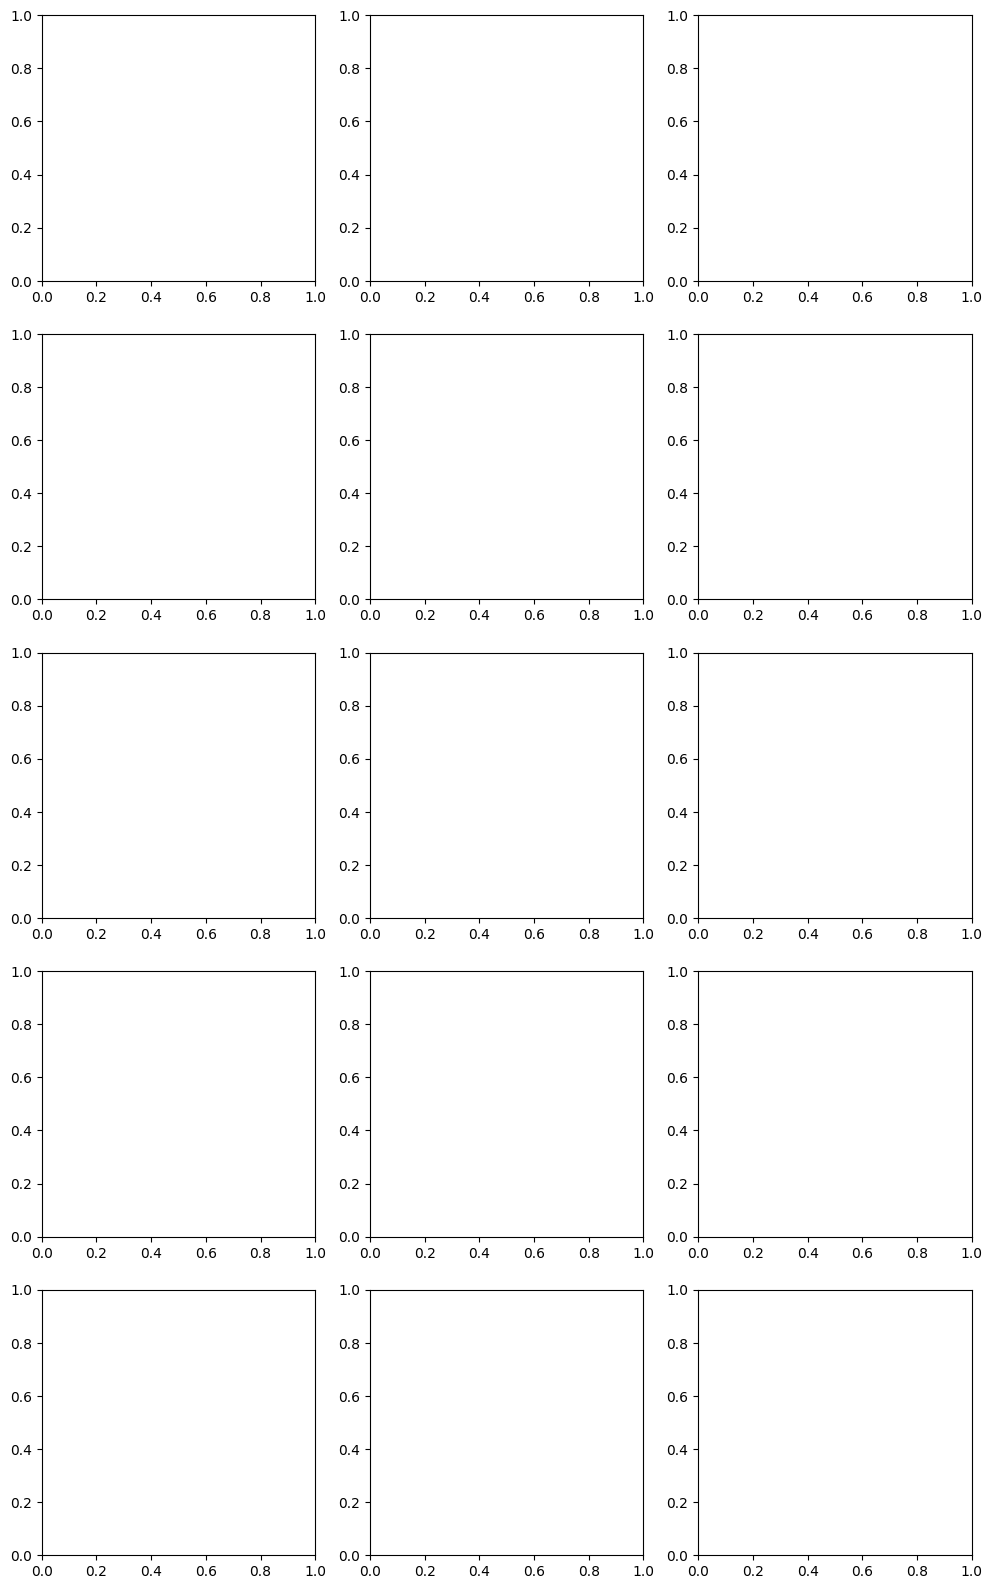

In [18]:
# === Блок 7: Инференс и визуализация сегментации ===

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch

# Выбираем несколько примеров для визуализации
n_show = 5
indices = random.sample(range(len(ds_seg)), min(n_show, len(ds_seg)))

fig, axes = plt.subplots(n_show, 3, figsize=(12, 4*n_show))

for row, idx in enumerate(indices):
    # Получаем данные из датасета
    sample = ds_seg[idx]
    
    # Проверяем формат возврата датасета
    if isinstance(sample, tuple) and len(sample) == 2:
        img_pil, gt_mask = sample
    else:
        # Если датасет возвращает dict или другой формат
        if isinstance(sample, dict):
            img_pil = sample.get('image', sample.get('img', None))
            gt_mask = sample.get('mask', sample.get('segmentation', sample.get('label', None)))
        else:
            raise ValueError(f"Неизвестный формат данных: {type(sample)}")
    
    # Конвертируем изображение в numpy array для отображения
    if isinstance(img_pil, Image.Image):
        img_np = np.array(img_pil)
    elif isinstance(img_pil, np.ndarray):
        img_np = img_pil
    else:
        raise ValueError(f"Неизвестный формат изображения: {type(img_pil)}")
    
    # Обрабатываем ground truth маску
    if isinstance(gt_mask, Image.Image):
        # Если это PIL Image в режиме 'P' (palette), конвертируем в 'L' (grayscale)
        if gt_mask.mode == 'P':
            gt_pil = gt_mask.convert('L')
        elif gt_mask.mode != 'L':
            gt_pil = gt_mask.convert('L')
        else:
            gt_pil = gt_mask
        gt_np = np.array(gt_pil)
    elif isinstance(gt_mask, np.ndarray):
        gt_np = gt_mask
    elif isinstance(gt_mask, torch.Tensor):
        gt_np = gt_mask.numpy()
    elif isinstance(gt_mask, int):
        # Если это просто класс (не маска), создаем фиктивную маску
        print(f"Warning: ground truth - integer {gt_mask}, создаем фиктивную маску")
        gt_np = np.zeros_like(img_np[:, :, 0]) if len(img_np.shape) == 3 else np.zeros_like(img_np)
    else:
        raise ValueError(f"Неизвестный формат ground truth: {type(gt_mask)}")
    
    # Запускаем инференс модели
    with torch.no_grad():
        # Применяем трансформации к изображению
        input_tensor = preprocess(img_pil).unsqueeze(0).to(DEVICE)
        
        # Получаем предсказание
        output = model(input_tensor)['out'][0]
        
        # Получаем маску человека (класс PERSON_IDX)
        pred_mask = (output.argmax(0) == PERSON_IDX).byte().cpu().numpy()
    
    # Визуализация
    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f"Image {idx+1}")
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(gt_np, cmap='gray')
    axes[row, 1].set_title("Ground Truth")
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(pred_mask, cmap='gray')
    axes[row, 2].set_title("Prediction")
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

print("Инференс завершен!")

In [15]:
# 8. Финальное сохранение runs.csv
df_seg = pd.DataFrame(seg_results) if seg_results else pd.DataFrame()
df_seg['dataset'] = 'OxfordIIITPet'
df_seg['seed'] = SEED
df_seg['model_summary'] = 'DeepLabV3-ResNet50'
df_seg['optimizer'] = 'N/A'
df_seg['lr'] = 0
df_seg['epochs_trained'] = 0
df_seg['best_val_accuracy'] = None
df_seg['test_accuracy'] = None
df_seg['precision'] = None
df_seg['recall'] = None

df_full = pd.concat([df_clf, df_seg], ignore_index=True)
df_full.to_csv(os.path.join(ARTIFACTS_DIR, "runs.csv"), index=False)
print("runs.csv saved.")
print(df_full[['experiment_id', 'task', 'best_val_accuracy', 'mean_iou']])

runs.csv saved.
  experiment_id            task best_val_accuracy mean_iou
0            C1  classification             0.365     None
1            C2  classification              0.31     None
2            C3  classification              0.63     None
3            C4  classification              0.79     None
